In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns

In [31]:
from sklearn.covariance import EmpiricalCovariance

In [16]:
from sklearn.preprocessing import StandardScaler

In [2]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn import datasets 

In [3]:
def scatter_helper(ax, xs, ys, zs=None, class_label = None):

    """
    plot a 2d or 3d scatter plot and color using given class labels if any
    """

    if zs is not None:
        if class_label is not None:
            sc = ax.scatter(xs, ys, zs, c=class_label, cmap='tab10', s=10)
        else:
            sc = ax.scatter(xs, ys, zs, s=10)
        return sc

    else:
        if class_label is not None:
            sc = ax.scatter(xs, ys, c=class_label, cmap='tab10', s=10)
        else:
            sc = ax.scatter(xs, ys, s=10)
        return sc
    
    return None

def plot_3d_scatters(X,title_name,y=None,custom_inx=[0,1,2]):

    """
    plot 4 subplots: 1st is a 3d scatter plot, the other 3 show 2d / pairwise marginals
    """

    fig, axs = plt.subplots(1, 4, figsize=(15, 3), subplot_kw={})

    axs[0] = fig.add_subplot(1, 4, 1, projection='3d')
    xs,ys,zs = X[:, custom_inx[0]], X[:, custom_inx[1]], X[:, custom_inx[2]]
    scatter_helper(axs[0],xs,ys,zs,y)
    axs[0].set_title(title_name)

    # 2D scatter plots
    scatter_helper(axs[1],xs,ys,None,y)
    axs[1].set_title(f'{custom_inx[0]} vs {custom_inx[1]}')

    scatter_helper(axs[2],ys,zs,None,y)
    axs[2].set_title(f'{custom_inx[1]} vs {custom_inx[2]}')

    scatter_helper(axs[3],xs,zs,None,y)
    axs[3].set_title(f'{custom_inx[0]} vs {custom_inx[2]}')
        
    # plt.xlim(-2.5, 2.5)
    # plt.ylim(-2.5, 2.5)

    plt.tight_layout()
    plt.show()


In [4]:
def noisy_torus(n_samples=1000, R=2, r=1, noise=0.2, random_state=None, center=(0, 0, 0)):
    rng = np.random.default_rng(random_state)
    
    # Sample angles u, v uniformly
    u = rng.uniform(0, 2 * np.pi, n_samples)
    v = rng.uniform(0, 2 * np.pi, n_samples)
    
    # Parametric equations
    x = (R + r * np.cos(v)) * np.cos(u)
    y = (R + r * np.cos(v)) * np.sin(u)
    z = r * np.sin(v)
    
    # Add Gaussian noise if requested
    if noise > 0:
        x += rng.normal(0, noise, n_samples)
        y += rng.normal(0, noise, n_samples)
        z += rng.normal(0, noise, n_samples)
    
    return np.stack([x, y, z], axis=1)


In [5]:
seed = 42

In [6]:
n_samples = 1000
torus_points = noisy_torus(n_samples=n_samples,noise=0.0,random_state=seed,R=2,r=0.5)

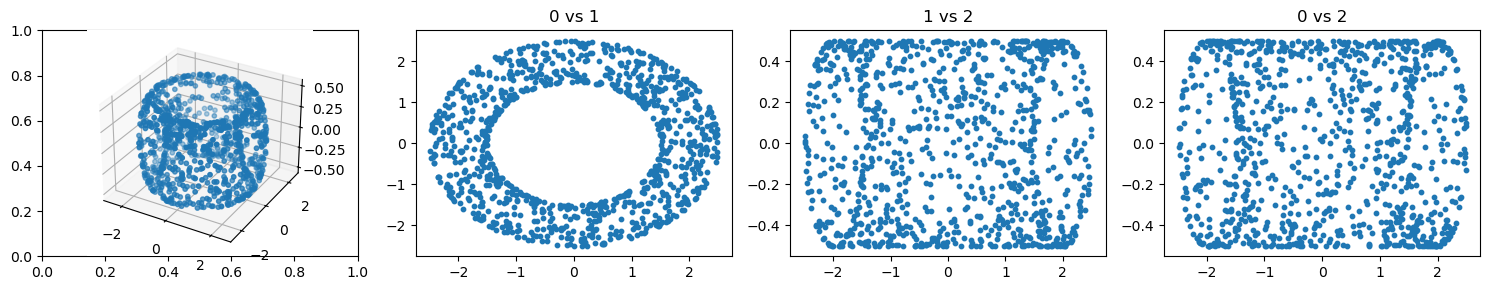

In [7]:
plot_3d_scatters(torus_points,'')

In [8]:
n_columns = 10

In [9]:
random_state_lst = [np.random.randint(1e6) for j in range(n_columns)]

In [69]:
from sklearn.feature_selection import mutual_info_regression
# from sklearn.covariance import EmpiricalCovariance, MinCovDet

def continuous_mi_matrix(X,dim=1):
    n = X.shape[1]
    mi_matrix = np.zeros((n, n))
    
    for i in range(n):
        y = X[:, i]
        for j in range(n):
            if i == j:
                mi_matrix[i, j] = 0  # MI with itself isn't informative
            else:
                mi_matrix[i, j] = mutual_info_regression(X[:, [j]], y, discrete_features=False)[0]
    
    return mi_matrix


In [10]:
# GPREGRESSOR DOES NOT WORK WELL FOR PRIOR SAMPLING
# JUST WRITE YOUR OWN USING NUMPY
# X_clean = np.zeros((n_samples, n_columns))

# kernel = RBF(length_scale=0.01)

# for j in range(n_columns):
#     gp = GaussianProcessRegressor(kernel=kernel, random_state=random_state_lst[j])
#     X_clean[:, j] = gp.sample_y(torus_points, n_samples=1).flatten()

In [11]:
# plot_3d_scatters(X_clean,'')

In [12]:
# noise_scale = 0.1
# noise = noise_scale * np.random.randn(n_samples, n_columns)

# X = X_clean + noise

# X = StandardScaler().fit_transform(X)
# plot_3d_scatters(X,'')

In [221]:
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel

def sample_latent_variables(n, d, latent_sampler):
    return latent_sampler(n, d)

def gp_kernel(Z, length_scale=1.0, sigma_f=1.0):
    """compute the RBF kernel matrix for latent space Z"""
    return sigma_f**2 * rbf_kernel(Z, Z, gamma=1.0 / (2 * length_scale**2))

def generate_gp_functions(Z, p, length_scale=1.0, sigma_f=1.0):
    """
    generate p Gaussian process samples evaluated at Z
    """
    n = Z.shape[0]
    K = gp_kernel(Z, length_scale=length_scale, sigma_f=sigma_f)
    # Add small jitter for numerical stability
    K += 1e-6 * np.eye(n)
    return np.random.multivariate_normal(mean=np.zeros(n), cov=K, size=p).T

def generate_noise(n, p, sigma):
    return sigma * np.random.randn(n, p)

def latent_metric_model_gp(n, p, d, sigma, latent_sampler, length_scale=1.0, sigma_f=1.0):
    Z = sample_latent_variables(n, d, latent_sampler)
    Y_clean = generate_gp_functions(Z, p, length_scale, sigma_f)
    noise = generate_noise(n, p, sigma)
    Y = Y_clean + noise
    return Y, Z

def torus_sampler(n, R=2.0, r=0.5):
    """
    sample n points on a torus of major radius R and minor radius r
    return array of shape (n, 3)
    """
    theta = 2 * np.pi * np.random.rand(n)
    phi = 2 * np.pi * np.random.rand(n)
    x = (R + r * np.cos(phi)) * np.cos(theta)
    y = (R + r * np.cos(phi)) * np.sin(theta)
    z = r * np.sin(phi)
    return np.stack([x, y, z], axis=1)

from sklearn.datasets import make_swiss_roll

def swiss_roll_sampler(n, noise=0.0):
    Z, _ = make_swiss_roll(n_samples=n, noise=noise)
    return Z 

from sklearn.datasets import make_s_curve

def s_curve_sampler(n, noise=0.0):
    Z, _ = make_s_curve(n_samples=n, noise=noise)
    return Z

n, p, d, sigma = 1000, 100, 3, 0.0
Y, Z = latent_metric_model_gp(n, p, d, sigma, torus_sampler, length_scale=1.0)


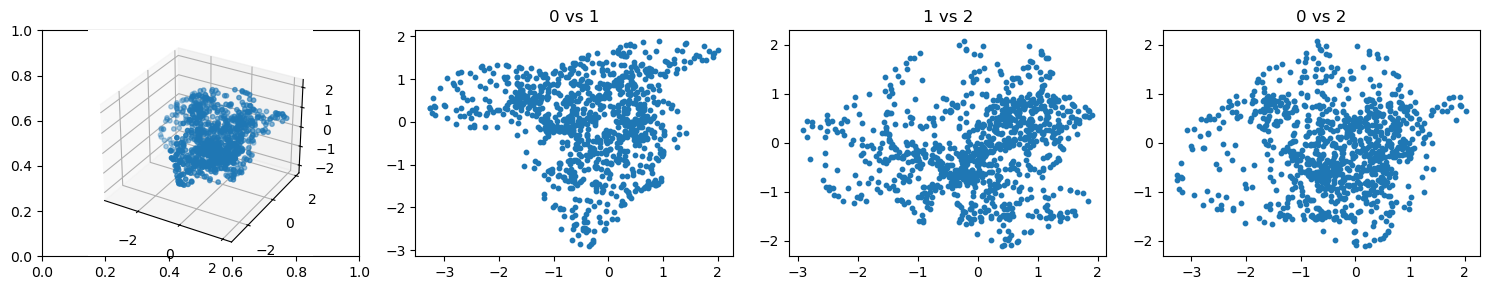

In [222]:
plot_3d_scatters(Y,'')

In [291]:
X = make_heteroskedastic_anisotropic_blobs_nd(n_samples = n, n_features = p,centers=5,random_state = 2450,scale_factor=1000)
X = StandardScaler().fit_transform(X[0])

In [292]:
# X = StandardScaler().fit_transform(Y)

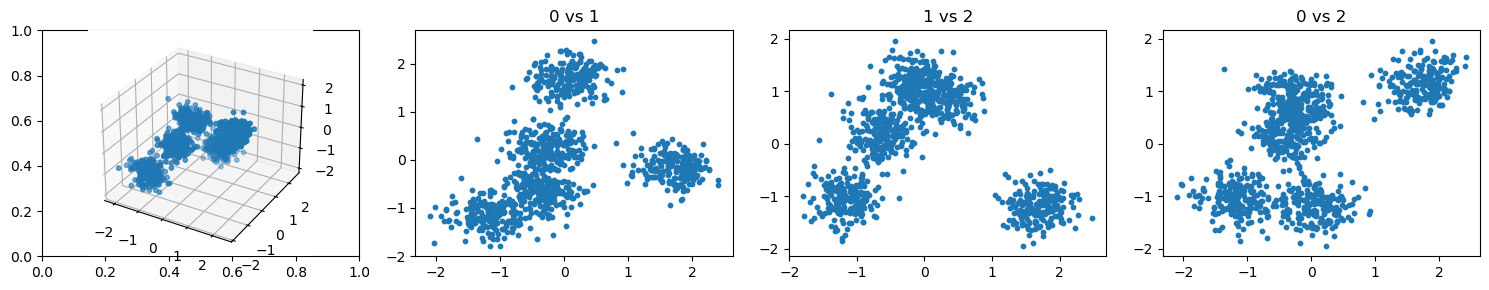

In [293]:
plot_3d_scatters(X,'')

In [294]:
from sklearn.decomposition import PCA
pca = PCA(n_components=min(n,p))
pca.fit(X.T)

,n_components,100
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


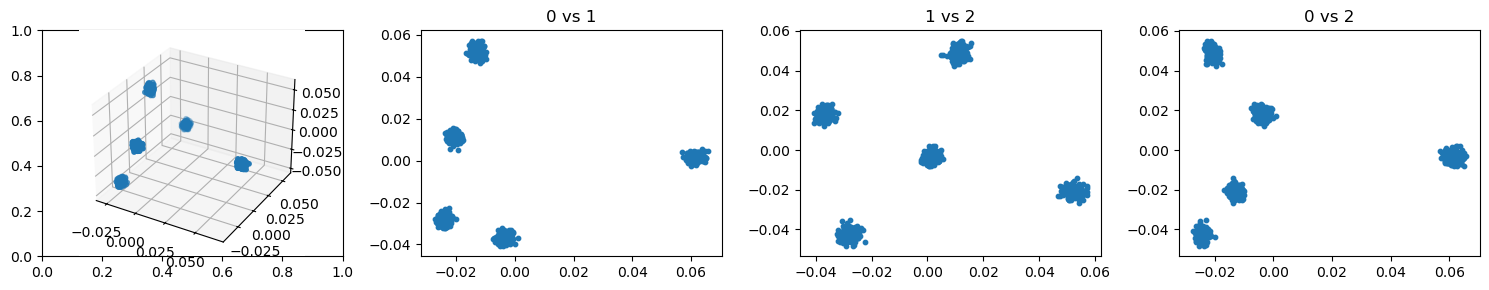

In [295]:
plot_3d_scatters(pca.components_.T,'')

In [296]:
summed_var = np.cumsum(pca.explained_variance_ratio_)

In [297]:
# len(summed_var)

In [298]:
null_ratio = [1/len(summed_var) for i in range(len(summed_var))]
null_summed = np.cumsum(null_ratio)

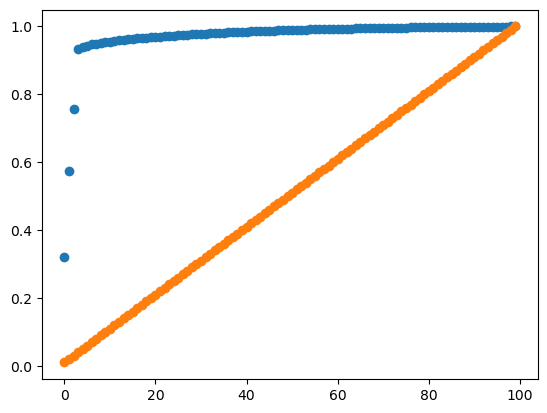

In [299]:
plt.scatter(y = summed_var, x = range(len(summed_var)))
plt.scatter(y = null_summed, x = range(len(summed_var)))

In [300]:
cov_estimator = EmpiricalCovariance().fit(X)
cov_mat = cov_estimator.covariance_

In [301]:
eigs = np.linalg.eigvals(cov_mat)

In [302]:
mi_mtx = continuous_mi_matrix(X)

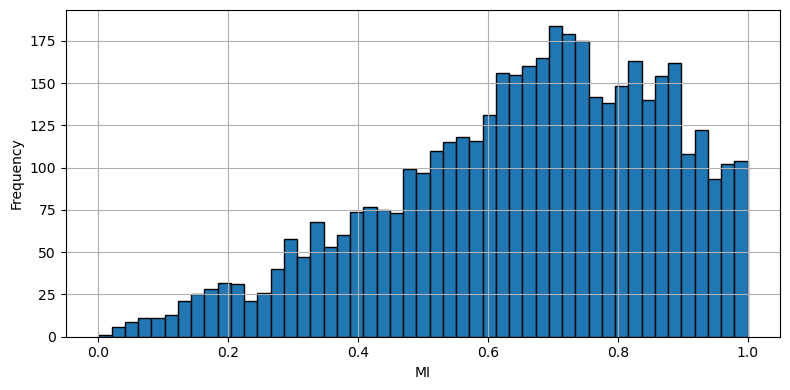

In [303]:
plot_upperTri_mtx(mi_mtx,'MI','',bins=np.linspace(0,1,50))

In [304]:
# cov_mat

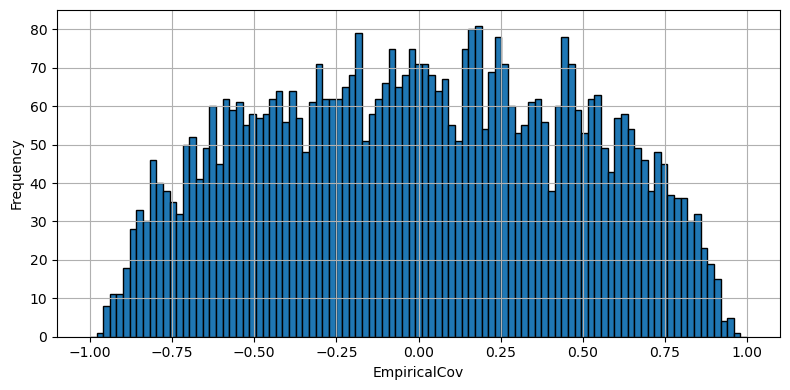

In [305]:
plot_upperTri_mtx(cov_mat,'EmpiricalCov','',bins=np.linspace(-1,1,100))

In [288]:
cov_norm = cov_mat / np.trace(cov_mat)
eigs_norm = np.linalg.eigvals(cov_norm)
print(f'sum of normalized eigenvals : {np.sum(eigs_norm)}')
print(f'entropy: {-np.sum(eigs_norm * np.log(eigs_norm))}')

sum of normalized eigenvals : 1.0000000000000004
entropy: 4.075924700107993


In [289]:
eigs_sorted = np.sort(eigs)[::-1]

Text(0.5, 1.0, 'eigenvals of cov')

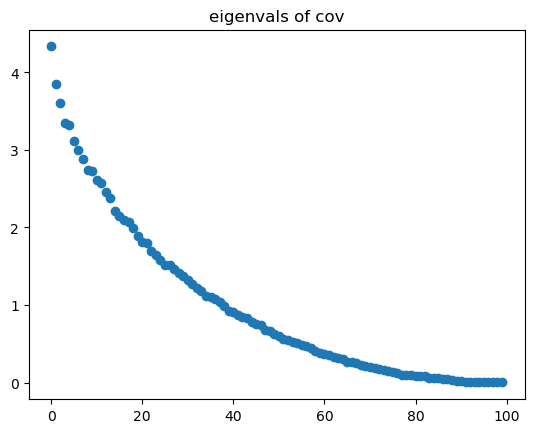

In [290]:
plt.scatter(y = eigs_sorted, x = range(len(eigs)))
plt.title('eigenvals of cov')

In [158]:
# plot_empirical_cov(X,'')

In [39]:
# plot_dist_distribution(X,point='all',dist_scale='none')

In [183]:
def make_heteroskedastic_anisotropic_blobs_nd(
    n_samples=1000, n_features=3, cluster_std=1.0, 
    transforms=None, random_state=None,centers=1,scale_factor=100.0):

    """    
    """
    
    if isinstance(cluster_std, float):
        # num_center = 1
        pass
    elif isinstance(cluster_std, list):
        assert centers == len(cluster_std)
    else:
        # raise error
        return

    # generate gaussian blobs first
    X, y = datasets.make_blobs(
        n_samples=n_samples,
        n_features=n_features,
        cluster_std=cluster_std,
        random_state=random_state,
        centers=centers
    )

    # create a random transform to stretch these blobs in diff ways and make them anisotropic
    # right now -> doing it label wise / per cluster but can also do a global transform
    unique_labels = np.unique(y)
    rng = np.random.default_rng(random_state)
    # scale_factor = 10.0
    if transforms is None:
        transforms = {
            label: rng.normal(size=(n_features, n_features))*scale_factor
            for label in unique_labels
        }

    X_transformed = np.zeros_like(X)

    for label in unique_labels:
        T = transforms[label]
        X_transformed[y == label] = X[y == label] @ T.T

    return X_transformed, y, transforms


In [250]:
def plot_upperTri_mtx(cov_mat,x_label,fig_title,absolute_vals=False,bins = np.linspace(0, 1, 50)):

    mask = np.triu(np.ones_like(cov_mat, dtype=bool), k=1)  

    # Extract off-diagonal, absolute positive values
    if absolute_vals:
        off_diag_vals = np.abs(cov_mat[mask])
    else:
        off_diag_vals = cov_mat[mask]

    # off_diag_vals = off_diag_vals[off_diag_vals !=0]  # filter out zeros
    
    plt.figure(figsize=(8, 4))
    plt.hist(off_diag_vals, bins=bins,edgecolor='black')
    plt.title(fig_title)
    plt.xlabel(x_label)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [67]:
def plot_empirical_cov(X,fig_title):
    cov_estimator = EmpiricalCovariance().fit(X)
    cov_mat = cov_estimator.covariance_

    mask = np.triu(np.ones_like(cov_mat, dtype=bool), k=1)  

    # Extract off-diagonal, absolute positive values
    off_diag_vals = np.abs(cov_mat[mask])
    off_diag_vals = off_diag_vals[off_diag_vals > 0]  # filter out zeros
    
    plt.figure(figsize=(8, 4))
    plt.hist(off_diag_vals, bins=np.linspace(0, 1, 50), edgecolor='black')
    plt.title(fig_title)
    plt.xlabel("Covariance value")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()